# Advanced Loss Functions & Parameter Tuning

## Basic Loss Functions

A **loss function** is used in NN model to optimize the parameter values. Loss function can be classified 2 two broad categories:

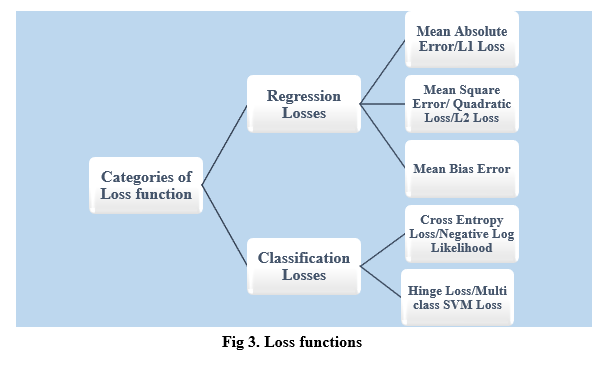

Following table compares the frequently used loss function in deep learning for regression and classification task respectively.

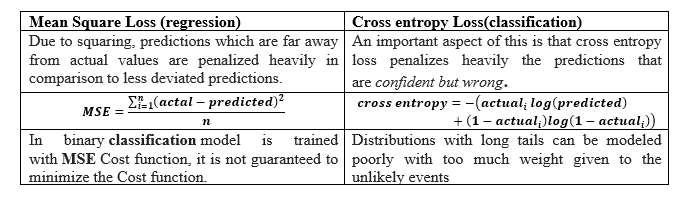

# Project - Demonstration of most used Loss function as optimization algorithm using CNN for MNIST.

## Installing Packages

In [1]:
%pip install keras tensorflow matplotlib keras-adabound


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Importing Libraries

In [2]:
from keras.datasets import mnist # Import MNIST dataset
import tensorflow # Import TensorFlow
from tensorflow.keras.models import Sequential # Import Sequential model
from tensorflow.keras.layers import Dense, Flatten # Import necessary layers
from tensorflow.keras.layers import Conv2D, MaxPooling2D # Import convolutional and pooling layers
from tensorflow.keras.layers import BatchNormalization # Import Batch Normalization layer
import matplotlib.pyplot as plt # Import Matplotlib for plotting
from keras_adabound import AdaBound # AdaBound optimizer

2025-06-18 10:26:19.736887: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-18 10:26:24.517562: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-18 10:26:26.740177: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750242390.242445    1761 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750242391.155824    1761 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1750242398.456438    1761 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

## Model configuration 


In [3]:
batch_size = 250
no_epochs = 5
no_classes = 10
validation_split = 0.2
verbosity = 1

## Load MNIST dataset

In [4]:
(input_train, target_train), (input_test, target_test) =mnist.load_data()

## Shaping & Reshaping

In [5]:
# Shape of the input sets
input_train_shape = input_train.shape
input_test_shape = input_test.shape

# Keras layer input shape
input_shape = (input_train_shape[1], input_train_shape[2], 1)
# Reshape the training data to include channels
input_train = input_train.reshape(input_train_shape[0], input_train_shape[1], input_train_shape[2], 1)
input_test = input_test.reshape(input_test_shape[0], input_test_shape[1], input_test_shape[2], 1)

## Parsing & Normalization

In [6]:
# Parse numbers as floats
input_train = input_train.astype('float32')
input_test = input_test.astype('float32')
# Normalize input data
input_train = input_train / 255
input_test = input_test / 255

## Building Model

In [7]:
model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=input_shape))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(BatchNormalization())
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(BatchNormalization())
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(BatchNormalization())
model.add(Dense(no_classes, activation='softmax'))

/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-06-18 10:27:10.802150: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## Compiling the model

### Adagrad Optimizer

In [8]:
model.compile(loss=tensorflow.keras.losses.sparse_categorical_crossentropy, optimizer=tensorflow.keras.optimizers.Adagrad( learning_rate=0.001, initial_accumulator_value=0.1, epsilon=1e-07))

### Adadelta Optimizer

In [9]:
model.compile(loss=tensorflow.keras.losses.sparse_categorical_crossentropy, optimizer = tensorflow.keras.optimizers.Adadelta(learning_rate=0.001, rho=0.95, epsilon=1e-07, name="Adadelta"))

### Adam - Adaptive Momentum Estimation

In [10]:
model.compile(loss=tensorflow.keras.losses.sparse_categorical_crossentropy,
optimizer=tensorflow.keras.optimizers.Adam(learning_rate=0.01),
metrics=['accuracy'])

### Adabound momentum estimation

In [11]:
# Patching AdaBound because of a bug in keras-adabound that I am unable to fix
from tensorflow.keras.optimizers import Optimizer

class AdaBound(Optimizer):
    def __init__(self, learning_rate=1e-3, final_lr=0.1, name="AdaBound", **kwargs):
        super().__init__(learning_rate=learning_rate, name=name, **kwargs)
        self.final_lr = final_lr

    def get_config(self):
        config = super().get_config()
        config.update({
            "learning_rate": self.learning_rate,
            "final_lr": self.final_lr,
        })
        return config

    def update_step(self, grad, variable, learning_rate=None):
        if learning_rate is None:
            learning_rate = self.learning_rate

        # Implement the AdaBound update logic here
        # This is a simplified version; actual implementation may vary
        variable.assign_sub(learning_rate * grad)
        return variable    

optimizer = AdaBound(learning_rate=1e-3, final_lr=0.1)
model.compile(optimizer=optimizer, loss=tensorflow.keras.losses.sparse_categorical_crossentropy)

## Fitting & Generation

In [12]:
from tensorflow.keras.optimizers import Adagrad, Adadelta, Adam

# List of optimizers and their names
optimizers = [
    ("Adagrad", Adagrad(learning_rate=0.001, initial_accumulator_value=0.1, epsilon=1e-07)),
    ("Adadelta", Adadelta(learning_rate=0.001, rho=0.95, epsilon=1e-07, name="Adadelta")),
    ("Adam", Adam(learning_rate=0.01)),
    ("AdaBound", AdaBound(learning_rate=1e-3, final_lr=0.1))
]

results = {}

for name, opt in optimizers:
    # Build a fresh model each time
    model = Sequential()
    model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(BatchNormalization())
    model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(BatchNormalization())
    model.add(Flatten())
    model.add(Dense(256, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dense(no_classes, activation='softmax'))

    model.compile(loss=tensorflow.keras.losses.sparse_categorical_crossentropy, optimizer=opt, metrics=['accuracy'])
    print(f"\nTraining with {name} optimizer:")
    history = model.fit(
        input_train, target_train,
        batch_size=batch_size,
        epochs=no_epochs,
        verbose=verbosity,
        validation_split=validation_split
    )
    score = model.evaluate(input_test, target_test, verbose=0)
    print(f'Test loss using {name}: {score[0]} / Test accuracy: {score[1]}')
    results[name] = (history, score)


Training with Adagrad optimizer:
Epoch 1/5


2025-06-18 10:27:11.597291: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 150528000 exceeds 10% of free system memory.


192/192 ━━━━━━━━━━━━━━━━━━━━ 47s 225ms/step - accuracy: 0.6329 - loss: 1.1861 - val_accuracy: 0.1060 - val_loss: 3.6362
Epoch 2/5
192/192 ━━━━━━━━━━━━━━━━━━━━ 83s 237ms/step - accuracy: 0.9195 - loss: 0.2870 - val_accuracy: 0.2278 - val_loss: 2.4267
Epoch 3/5
192/192 ━━━━━━━━━━━━━━━━━━━━ 67s 157ms/step - accuracy: 0.9421 - loss: 0.2078 - val_accuracy: 0.8990 - val_loss: 0.3965
Epoch 4/5
192/192 ━━━━━━━━━━━━━━━━━━━━ 31s 163ms/step - accuracy: 0.9531 - loss: 0.1687 - val_accuracy: 0.9582 - val_loss: 0.1593
Epoch 5/5
192/192 ━━━━━━━━━━━━━━━━━━━━ 40s 160ms/step - accuracy: 0.9593 - loss: 0.1485 - val_accuracy: 0.9643 - val_loss: 0.1308
Test loss using Adagrad: 0.1283203810453415 / Test accuracy: 0.9656000137329102

Training with Adadelta optimizer:
Epoch 1/5


2025-06-18 10:31:52.877330: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 150528000 exceeds 10% of free system memory.


192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.1105 - loss: 2.9178

2025-06-18 10:32:25.767321: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 37632000 exceeds 10% of free system memory.


192/192 ━━━━━━━━━━━━━━━━━━━━ 35s 168ms/step - accuracy: 0.1106 - loss: 2.9170 - val_accuracy: 0.1167 - val_loss: 2.4159
Epoch 2/5
192/192 ━━━━━━━━━━━━━━━━━━━━ 32s 165ms/step - accuracy: 0.2580 - loss: 2.2545 - val_accuracy: 0.1418 - val_loss: 2.3989
Epoch 3/5
192/192 ━━━━━━━━━━━━━━━━━━━━ 41s 165ms/step - accuracy: 0.4195 - loss: 1.7619 - val_accuracy: 0.3711 - val_loss: 1.8203
Epoch 4/5
192/192 ━━━━━━━━━━━━━━━━━━━━ 45s 186ms/step - accuracy: 0.5433 - loss: 1.4048 - val_accuracy: 0.6178 - val_loss: 1.2202
Epoch 5/5
192/192 ━━━━━━━━━━━━━━━━━━━━ 33s 170ms/step - accuracy: 0.6445 - loss: 1.1348 - val_accuracy: 0.7047 - val_loss: 0.9593
Test loss using Adadelta: 0.9558579921722412 / Test accuracy: 0.7074000239372253

Training with Adam optimizer:
Epoch 1/5


2025-06-18 10:35:08.627449: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 150528000 exceeds 10% of free system memory.


192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.9256 - loss: 0.2536

2025-06-18 10:35:40.554465: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 37632000 exceeds 10% of free system memory.


192/192 ━━━━━━━━━━━━━━━━━━━━ 34s 165ms/step - accuracy: 0.9258 - loss: 0.2528 - val_accuracy: 0.1060 - val_loss: 16.2879
Epoch 2/5
192/192 ━━━━━━━━━━━━━━━━━━━━ 31s 159ms/step - accuracy: 0.9864 - loss: 0.0403 - val_accuracy: 0.6587 - val_loss: 1.0482
Epoch 3/5
192/192 ━━━━━━━━━━━━━━━━━━━━ 41s 160ms/step - accuracy: 0.9910 - loss: 0.0281 - val_accuracy: 0.9870 - val_loss: 0.0429
Epoch 4/5
192/192 ━━━━━━━━━━━━━━━━━━━━ 31s 162ms/step - accuracy: 0.9947 - loss: 0.0147 - val_accuracy: 0.8878 - val_loss: 0.3908
Epoch 5/5
192/192 ━━━━━━━━━━━━━━━━━━━━ 30s 158ms/step - accuracy: 0.9944 - loss: 0.0178 - val_accuracy: 0.9844 - val_loss: 0.0666
Test loss using Adam: 0.06071540713310242 / Test accuracy: 0.9828000068664551

Training with AdaBound optimizer:
Epoch 1/5
192/192 ━━━━━━━━━━━━━━━━━━━━ 32s 159ms/step - accuracy: 0.4823 - loss: 1.6151 - val_accuracy: 0.1221 - val_loss: 2.7728
Epoch 2/5
192/192 ━━━━━━━━━━━━━━━━━━━━ 41s 160ms/step - accuracy: 0.8687 - loss: 0.4845 - val_accuracy: 0.3694 - val

## Plotting

In each case the model is executed and for first 5 epoch, loss and the accuracy are recorded. In order to study the performance of the optimizer with respect to cross entropy loss function, a graph was plotted.

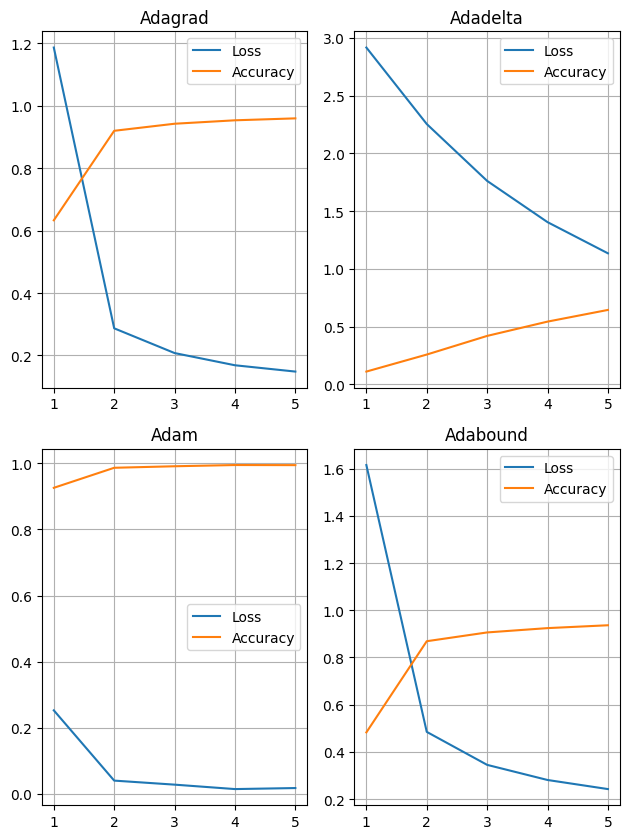

In [ ]:
x=[1,2,3,4,5]
Loss1=[1.1861,0.2870,0.2078,0.1687,0.1485]
accuracy1=[0.6329,0.9195,0.9421,0.9531,0.9593]
Loss2=[2.9170,2.2545,1.7619,1.4048,1.1348]
accuracy2=[0.1106,0.2580,0.4195,0.5433,0.6445]
Loss3=[0.2528,0.0403,0.0281,0.0147,0.0178]
accuracy3=[0.9258,0.9864,0.9910,0.9947,0.9944]
Loss4=[1.6153,0.4845,0.3447,0.2806,0.2421]
accuracy4=[0.4823,0.8687,0.9059,0.9242,0.9363]
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(6.4, 8.5))
#adgrad
axs[0, 0].plot(x, Loss1,  label="Loss")
axs[0, 0].plot(x, accuracy1, label="Accuracy")
axs[0, 0].legend()
axs[0, 0].grid()
axs[0, 0].set(title="Adagrad")
#Adadelta
axs[0, 1].plot(x, Loss2,  label="Loss")
axs[0, 1].plot(x, accuracy2, label="Accuracy")
axs[0, 1].legend()
axs[0, 1].grid()
axs[0, 1].set(title="Adadelta")
#Adam
axs[1, 0].plot(x, Loss3,  label="Loss")
axs[1, 0].plot(x, accuracy3, label="Accuracy")
axs[1, 0].legend()
axs[1, 0].grid()
axs[1, 0].set(title="Adam")
#Adabound
axs[1, 1].plot(x, Loss4,  label="Loss")
axs[1, 1].plot(x, accuracy4, label="Accuracy")
axs[1, 1].legend()
axs[1, 1].gr

#### Interpretation:
- **Adam:**
    Achieves the **lowest loss** and **highest accuracy** very quickly.
    Accuracy is close to 1.0 after just a few epochs.
    **Conclusion:** Adam is the best optimizer for this task among the four.

- **Adagrad:**
    Also performs well, with fast loss reduction and high accuracy, but not quite as good as Adam.
    **Conclusion:** Good for this task, but slightly less effective than Adam.

- **Adabound:**
    Shows similar trends to Adagrad, with good convergence and high accuracy.
    **Conclusion:** Performs well, but not better than Adam.

- **Adadelta:**
    Loss decreases steadily, but accuracy is much lower and improves slowly.
    **Conclusion:** Adadelta is the least effective optimizer for this task.

---

#### Overall Conclusion:

- **Adam** is the most effective optimizer for this CNN on MNIST, providing the fastest and highest accuracy. 
- **Adagrad** and **Adabound** are also good choices, but slightly less effective.
- **Adadelta** is not recommended for this problem, as it converges slowly and achieves lower accuracy.
- In practice, Adam is a strong default choice for most DL tasks.

---

## Advanced Loss Functions

Loss function can also define as algorithm which converts concepts to practical. So, it is a transformation function on neural networks which converts multiplication of matrix into deep learning.

Very recent or advanced loss functions in DL models are used for specific purposes and are as follows:

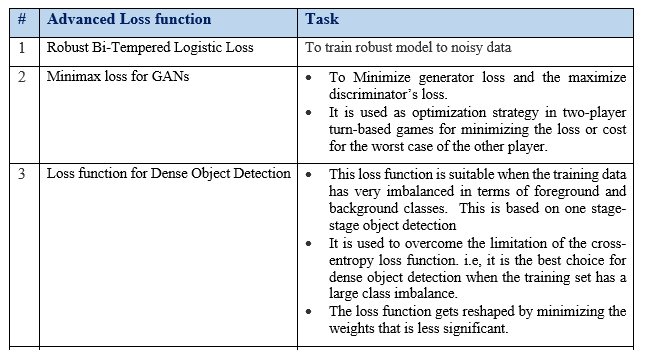
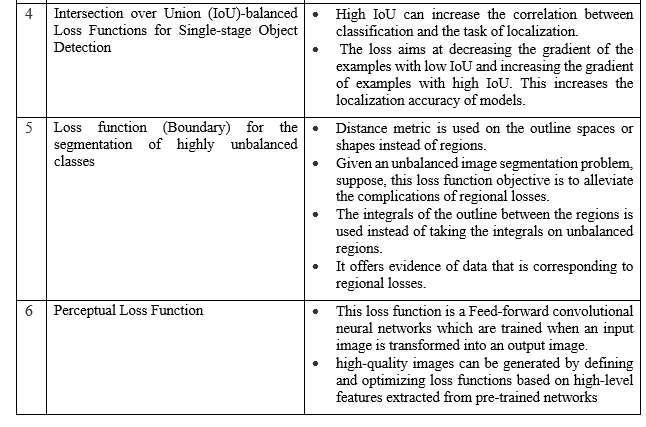

### Robust Bi-Tempered Logistic Loss

We know that, the DL model performance is dependent on the quality of training data. The real-world training data sets can be noisy. For example, corrupted images, mislabeled data are few noisy data sets. The Loss function can fail in handling the noisy training data due to the following 2 reasons:

1. **Highly deviated outliers:** Loss function like logistic Loss function are sensitive to outliers.

2. **Mislabeled data samples:** The neural network outputs the class label for each test sample by increasing the distance between the classes. During the process of increasing the decision boundary, the value of the loss function become reduced very fast, so that the training process tend to get close to the boundary of the outliers or mislabeled data samples. Consequently, prediction error occurs.

So, a robust loss function is required. “bi-tempered logistic loss function can be used to generalize he problem of noisy training data.

- As the name says, there are 2 modifiable parameters that can handle outliers and mislabeled data.  They are:
    “temperatures”—_t<sub>1</sub>_ : symbolizes the boundedness, and _t<sub>2</sub>_ : indicates the rate of decay in the termination or end of the transfer function
- initialize _t<sub>1</sub>_ and _t<sub>2</sub>_ to 1.0 so that, the logistic loss function is recovered.
- If _t<sub>1</sub>_ <  1.0 the boundedness gets increased and if _t<sub>2</sub>_ > 1.0 makes transfer function heavy tailed.


#### How to use Bi-Tempred Logisitc Loss?

Create a script file and run it.

```sh
#!/bin/bash
	set -e
	set -x
	
	virtualenv -p python3.
	source ./bin/activate
	
	pip install tensorflow
	pip install -r bitempered_loss/requirements.txt
	python -m bitempered_loss.loss_test
```

![Read More...](https://ai.googleblog.com/2019/08/bi-tempered-logistic-loss-for-training.html)

The usage of logistic loss using bi-tempered is proved by google for a binary or for 2-class classification problem with 2-layer on feed-forward neural network.

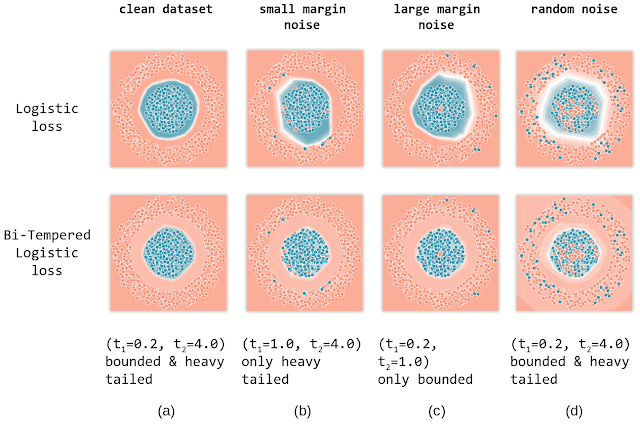

### GANs Loss Functions ( Minimax )

   - Generative adversarial networks (GAN) are a powerful subclass of generative models. 
   - 2 main components of GAN are Generator and Discriminator
   - This involves the minimization of the generator’s loss and maximization of the discriminator’s loss.
   - Discriminator loss aims at maximizing the probability given to real and fake images. This is a strategy aimed at reducing the worst-case-scenario possible loss. It’s simply minimizing the maximum loss. This loss is also used in 2-player games to reduce the maximum loss for a layer.


# Advanced Activation Functions 

## Parametric ReLU

It is a generalization of Leaky ReLU, where, the slope for negative inputs is not predetermined, rather it is considered as a learnable parameter. Formally, it is defined as,

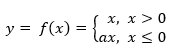

where the coefficient 'a' decides the slope of the negative part.

![alt text](4151600532709732-1.jpg)

The NN should learn the best value of itself along with the rest of the model.

Thus, when a=0, the function becomes ordinary ReLU. When  is a small and constant value, usually, 0.01, it becomes LReLU.

Even though we are adding one extra parameter to be learnt in this case, it is a negligible overhead when compared to the number of weights that are usually being learnt in DNNs.

The gradient of the PReLU function is given as –

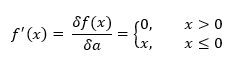

## ELU ( Exponential Linear Unit )

Exponential Linear Unit or ELU is similar to Leaky ReLU, but instead of a straight line, it uses a logarithmic curve for all the negative weighted sum of inputs as shown below:

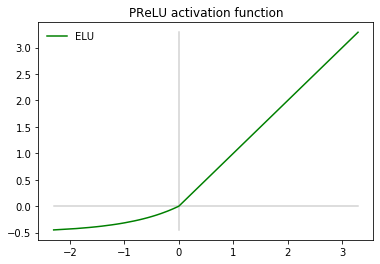

Mathematically, it is given by –

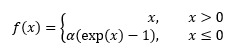

Where the ELU hyperparameter



and controls the value to which an ELU saturates for negative net inputs.

For backpropagation, its gradient of the activation is given by –

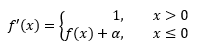

From the equation, we can see that ELUs diminish the vanishing gradient effect like ReLU and its variations, LReLU and PreLU

Similar to LReLU and PReLU, the negative values of ELU move the mean of the activations closer to zero. When the mean of the activations is closer to zero, learning is usually faster.

A significant improvement over LReLUs and PReLUs is that, for smaller arguments, an ELU saturates to a negative value. This implies smaller derivative which decreases the variation and the information that is passed on to the subsequent layer. This makes an ELU noise-robust as well as low-complex.

[Original paper](https://arxiv.org/abs/1511.07289)